# 🏡 Machine Learning for Design Inspiration Recommendation System

**Nhóm 13 – Machine Learning for Design | ĐHCN – ĐHQGHN**

---

### Pipeline tổng quan
```
User Query (text)
  → [1] Cài đặt & Import
  → [2] Load & Khám phá dữ liệu (EDA)
  → [3] Tiền xử lý (giữ nguyên từ nhóm)
  → [4] Train Style Classifier (RandomForest)
  → [5] Train Material Classifier (RandomForest)
  → [6] Train Color Regressor (MultiOutput RF)
  → [7] NLP Embedding (SentenceTransformer)
  → [8] Cosine Similarity Search
  → [9] Demo gợi ý đầy đủ
  → [10] Visualizations & Dashboard
  → [11] Lưu models
```

## 1. Cài đặt thư viện

In [22]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")


## 2. Load & Khám phá dữ liệu (EDA)

In [23]:
DATA_PATH = "dataset_cleaned_final.csv"
df = pd.read_csv(DATA_PATH)
df.head(5)

,Image_id,material_image_id,style_tags_boho,style_tags_industrial,style_tags_minimalist,style_tags_scandinavian,material_type_fabric,material_type_glass,material_type_leather,material_type_marble,material_type_metal,material_type_stone,material_type_tile,material_type_wood,clean_design_description,user_preference,color1,color2,color3
0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,The raw vibe of this bathroom is perfectly com...,"wants a modern, urban atmosphere",#3020D7,#02A235,#DE15E9
1,2,2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"This bathroom embraces a sleek design, highlig...",prefers simplicity and neutral palettes,#AE05EA,#341643,#2CA865
2,3,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"Incorporating visible ductwork, this urban bed...","wants a modern, urban atmosphere",#7D8FE0,#7B30A7,#83CE64
3,4,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Beautifully styled, this bedroom offers textur...",likes vibrant colors and handmade decor,#CD1C51,#897AD6,#C05A75
4,5,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,A serene living room featuring rough cladding ...,prefers simplicity and neutral palettes,#760885,#9D13F1,#4D0B0E


# ── Định nghĩa cột style / material# ── Định nghĩa cột style / material

In [24]:
STYLE_COLS    = ["style_tags_boho", "style_tags_industrial",
                 "style_tags_minimalist", "style_tags_scandinavian"]
MATERIAL_COLS = ["material_type_fabric", "material_type_glass",
                 "material_type_leather", "material_type_marble",
                 "material_type_metal", "material_type_stone",
                 "material_type_tile", "material_type_wood"]

In [25]:
STYLE_NAMES    = [c.replace("style_tags_", "").capitalize()    for c in STYLE_COLS]
MATERIAL_NAMES = [c.replace("material_type_", "").capitalize() for c in MATERIAL_COLS]

# Tạo cột label từ one-hot
df["style_label"]    = df[STYLE_COLS].fillna(0).idxmax(axis=1).str.replace("style_tags_", "").str.capitalize()
df["material_label"] = df[MATERIAL_COLS].fillna(0).idxmax(axis=1).str.replace("material_type_", "").str.capitalize()

# Làm sạch cột màu
df["color1"] = df["color1"].str.strip()
df["color2"] = df["color2"].str.strip()
df["color3"] = df["color3"].str.strip()

print("Style distribution:")
print(df["style_label"].value_counts())
print()
print("Material distribution:")
print(df["material_label"].value_counts())

Style distribution:
style_label
Boho            259
Industrial      251
Minimalist      246
Scandinavian    244
Name: count, dtype: int64

Material distribution:
material_label
Fabric     137
Stone      134
Leather    132
Wood       128
Marble     122
Metal      119
Tile       117
Glass      111
Name: count, dtype: int64


## 3. Tiền xử lý dữ liệu

> ✅ **Giữ nguyên code gốc từ notebook nhóm** – chỉ bổ sung phần chuẩn bị features cho ML models.

In [26]:
# ── CODE GỐC NHÓM: clean_text ────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Verify: áp dụng lại trên df (đã có trong dataset_cleaned_final.csv)
# df["clean_design_description"] = df["design_description"].apply(clean_text)
print("✓ clean_text function sẵn sàng")
print("Sample:", clean_text("Gian bếp tối giản bằng gỗ!"))

✓ clean_text function sẵn sàng
Sample: gian bếp tối giản bằng gỗ


In [27]:
# ── Chuẩn bị feature matrix & target vectors ─────────────────────────────────


# Tạo TF-IDF vectorizer cho văn bản mô tả thiết kế
# Dùng max_features=500 để giới hạn kích thước, loại bỏ stop words
tfidf_style = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_material = TfidfVectorizer(max_features=500, stop_words='english')

texts = df["clean_design_description"].fillna("").tolist()

X_style = tfidf_style.fit_transform(texts)
X_material = tfidf_material.fit_transform(texts)

# Lấy nhãn
y_style_idx = df[STYLE_COLS].fillna(0).values.argmax(axis=1)
y_style     = [STYLE_NAMES[i] for i in y_style_idx]

y_mat_idx   = df[MATERIAL_COLS].fillna(0).values.argmax(axis=1)
y_material  = [MATERIAL_NAMES[i] for i in y_mat_idx]

print(f"X_style shape:    {X_style.shape} (TF-IDF features)")
print(f"y_style labels:   {set(y_style)}")
print(f"X_material shape: {X_material.shape}")

X_style shape:    (1000, 247) (TF-IDF features)
y_style labels:   {'Boho', 'Minimalist', 'Industrial', 'Scandinavian'}
X_material shape: (1000, 247)


## 4. Mô hình phân loại Style (RandomForest Classifier)

In [28]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_style, y_style, test_size=0.2, random_state=42, stratify=y_style)

print(f"Train size (Style): {X_tr_s.shape[0]}")
print(f"Test size  (Style): {X_te_s.shape[0]}")

Train size (Style): 800
Test size  (Style): 200


In [29]:
# ── Huấn luyện ───────────────────────────────────────────────────────────────
style_clf = RandomForestClassifier(
    n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)
style_clf.fit(X_tr_s, y_tr_s)

y_pred_s = style_clf.predict(X_te_s)
acc_s    = accuracy_score(y_te_s, y_pred_s)
print(f"Style Classifier Accuracy: {acc_s:.4f}")
print()
print(classification_report(y_te_s, y_pred_s))

Style Classifier Accuracy: 0.9500

              precision    recall  f1-score   support

        Boho       0.91      0.98      0.94        52
  Industrial       0.98      0.98      0.98        50
  Minimalist       1.00      0.92      0.96        49
Scandinavian       0.92      0.92      0.92        49

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Huấn luyện mô hình so sánh (Support Vector Machine) ---
style_svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
style_svm_clf.fit(X_tr_s, y_tr_s)

# --- Dự đoán và Đánh giá ---
y_pred_svm = style_svm_clf.predict(X_te_s)
acc_svm = accuracy_score(y_te_s, y_pred_svm)

print(f"SVM Classifier Accuracy: {acc_svm:.4f}")
print("-" * 40)
print(classification_report(y_te_s, y_pred_svm))

SVM Classifier Accuracy: 0.9750
----------------------------------------
              precision    recall  f1-score   support

        Boho       0.98      0.96      0.97        52
  Industrial       1.00      0.98      0.99        50
  Minimalist       0.98      0.98      0.98        49
Scandinavian       0.94      0.98      0.96        49

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.98       200



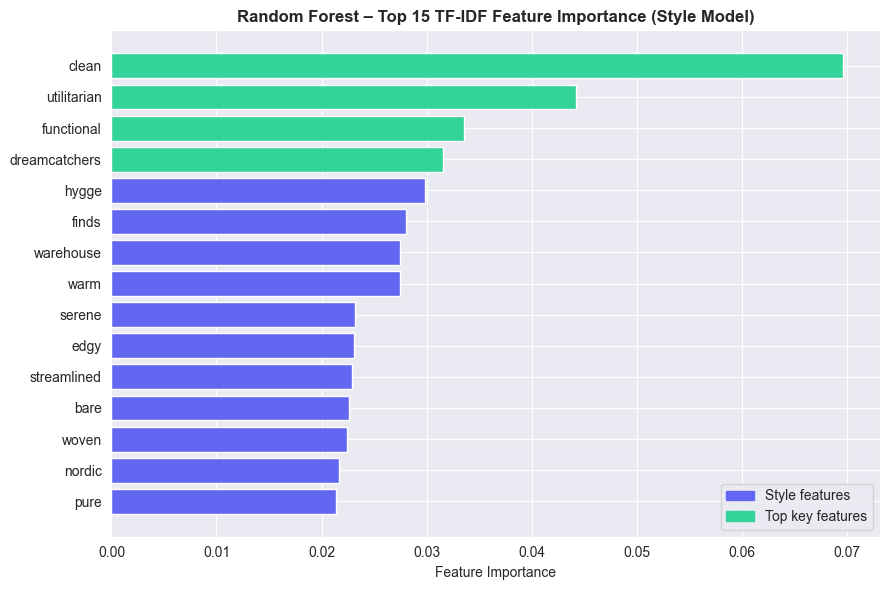

In [31]:
# ── Feature Importance: Style model ──────────────────────────────────────────
feat_names = tfidf_style.get_feature_names_out()
importances = style_clf.feature_importances_
n_top = 15
order = np.argsort(importances)[-n_top:]

plt.figure(figsize=(9, 6))
colors = ["#6366f1" if i < n_top - 4 else "#34d399" for i in range(n_top)]
plt.barh([feat_names[i] for i in order], importances[order], color=colors)
plt.xlabel("Feature Importance")
plt.title("Random Forest – Top 15 TF-IDF Feature Importance (Style Model)", fontweight="bold")

legend_elems = [mpatches.Patch(color="#6366f1", label="Style features"),
                mpatches.Patch(color="#34d399", label="Top key features")]
plt.legend(handles=legend_elems, loc="lower right")
plt.tight_layout()
plt.show()

## 5. Mô hình phân loại Material (RandomForest Classifier)

In [32]:
# ── Huấn luyện Material Classifier ─────────────────────────────────────────────
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_material, y_material, test_size=0.2, random_state=42, stratify=y_material)

material_clf = RandomForestClassifier(
    n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
material_clf.fit(X_tr_m, y_tr_m)

y_pred_m = material_clf.predict(X_te_m)
print(f"Accuracy (Material Model): {accuracy_score(y_te_m, y_pred_m):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_m, y_pred_m))

Accuracy (Material Model): 0.8800

Classification Report:
              precision    recall  f1-score   support

      Fabric       0.74      0.96      0.84        27
       Glass       1.00      0.91      0.95        22
     Leather       0.92      0.88      0.90        26
      Marble       0.81      0.84      0.82        25
       Metal       0.91      0.83      0.87        24
       Stone       0.86      0.93      0.89        27
        Tile       0.91      0.87      0.89        23
        Wood       1.00      0.81      0.89        26

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200



In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Huấn luyện mô hình so sánh (Support Vector Machine) ---
material_svm_clf = SVC(kernel='rbf', C=0.5, random_state=42)
material_svm_clf.fit(X_tr_m, y_tr_m)

# --- Dự đoán và Đánh giá ---
y_pred_svm = material_svm_clf.predict(X_te_m)
acc_svm = accuracy_score(y_te_m, y_pred_svm)

print(f"SVM Classifier Accuracy: {acc_svm:.4f}")
print("-" * 40)
print(classification_report(y_te_m, y_pred_svm))

SVM Classifier Accuracy: 0.9450
----------------------------------------
              precision    recall  f1-score   support

      Fabric       1.00      1.00      1.00        27
       Glass       1.00      0.91      0.95        22
     Leather       0.96      1.00      0.98        26
      Marble       0.85      0.92      0.88        25
       Metal       0.96      0.92      0.94        24
       Stone       0.87      0.96      0.91        27
        Tile       0.96      1.00      0.98        23
        Wood       1.00      0.85      0.92        26

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.94      0.95       200



## 6. Mô hình hồi quy màu sắc (MultiOutput RandomForest Regressor)

Dự đoán 9 giá trị (R,G,B) × 3 màu từ feature vector. Dataset dùng màu ngẫu nhiên nên R² thấp — đây là giới hạn dữ liệu, không phải lỗi mô hình.

In [34]:
# ── Chuẩn bị feature matrix & target vectors ─────────────────────────────────

# Tạo TF-IDF vectorizer cho văn bản mô tả thiết kế
# Dùng max_features=500 để giới hạn kích thước, loại bỏ stop words
tfidf_style = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_material = TfidfVectorizer(max_features=500, stop_words='english')

texts = df["clean_design_description"].fillna("").tolist()

X_style = tfidf_style.fit_transform(texts)
X_material = tfidf_material.fit_transform(texts)

# Lấy nhãn
y_style_idx = df[STYLE_COLS].fillna(0).values.argmax(axis=1)
y_style     = [STYLE_NAMES[i] for i in y_style_idx]

y_mat_idx   = df[MATERIAL_COLS].fillna(0).values.argmax(axis=1)
y_material  = [MATERIAL_NAMES[i] for i in y_mat_idx]

print(f"X_style shape:    {X_style.shape} (TF-IDF features)")
print(f"y_style labels:   {set(y_style)}")
print(f"X_material shape: {X_material.shape}")

X_style shape:    (1000, 247) (TF-IDF features)
y_style labels:   {'Boho', 'Minimalist', 'Industrial', 'Scandinavian'}
X_material shape: (1000, 247)


In [35]:
# ── Section 6: Color Regression Model ────────────────────────────────────────
def hex_to_rgb(hex_str: str) -> tuple:
    try:
        h = str(hex_str).strip().lstrip("#")
        return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    except Exception:
        return (128, 128, 128)

rgb_matrix = []
for _, row in df.iterrows():
    r1,g1,b1 = hex_to_rgb(row["color1"])
    r2,g2,b2 = hex_to_rgb(row["color2"])
    r3,g3,b3 = hex_to_rgb(row["color3"])
    rgb_matrix.append([r1,g1,b1, r2,g2,b2, r3,g3,b3])
y_color = np.array(rgb_matrix, dtype=float)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_style, y_color, test_size=0.2, random_state=42)

color_reg = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1))
color_reg.fit(X_tr_c, y_tr_c)

y_pred_c = color_reg.predict(X_te_c)
print(f"Color Model R² (test): {r2_score(y_te_c, y_pred_c, multioutput='uniform_average'):.4f}")


Color Model R² (test): -0.0125


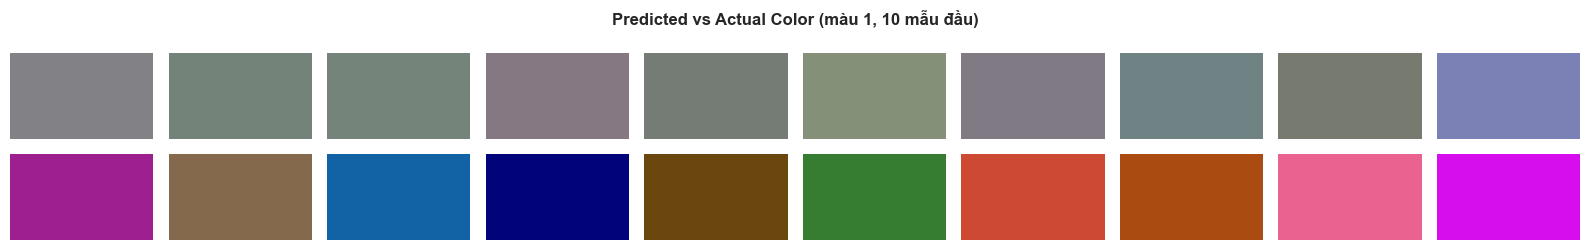

In [36]:
# ── Visualize predicted vs actual colors (10 mẫu đầu) ─────────────────────
n_show = 10
pred_clipped = np.clip(y_pred_c[:n_show], 0, 255).astype(int)
actual        = y_te_c[:n_show].astype(int)

fig, axes = plt.subplots(2, n_show, figsize=(16, 2.5))
for i in range(n_show):
    # Predicted
    rgb_p = tuple(int(v) for v in pred_clipped[i, 0:3])
    axes[0, i].add_patch(plt.Rectangle((0,0),1,1,
        color=[v/255 for v in rgb_p]))
    axes[0, i].set_xlim(0,1); axes[0, i].set_ylim(0,1)
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_ylabel("Pred", fontsize=9)

    # Actual
    rgb_a = tuple(int(v) for v in actual[i, 0:3])
    axes[1, i].add_patch(plt.Rectangle((0,0),1,1,
        color=[v/255 for v in rgb_a]))
    axes[1, i].set_xlim(0,1); axes[1, i].set_ylim(0,1)
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_ylabel("Actual", fontsize=9)

fig.suptitle("Predicted vs Actual Color (màu 1, 10 mẫu đầu)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. NLP Embedding – SentenceTransformer

Dùng `all-MiniLM-L6-v2` để chuyển câu mô tả → vector 384 chiều.  
Embedding được cache vào `description_embeddings.pkl` để tránh encode lại.

In [37]:
print("Loading SentenceTransformer all-MiniLM-L6-v2 …")
st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✓ Model loaded")

# In-memory cache
_query_cache = {}

def encode_query(text: str) -> np.ndarray:
    if text not in _query_cache:
        _query_cache[text] = st_model.encode([text], normalize_embeddings=True)
    return _query_cache[text]


Loading SentenceTransformer all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11442.24it/s]


✓ Model loaded


In [38]:
# ── Encode toàn bộ dataset (cache vào file) ──────────────────────────────────

EMB_PATH = "description_embeddings.pkl"
ST_MODEL_NAME = "all-MiniLM-L6-v2"

dataset_embeddings = None
if os.path.exists(EMB_PATH):
    cached_data = joblib.load(EMB_PATH)
    if isinstance(cached_data, dict) and cached_data.get("model_name") == ST_MODEL_NAME:
        dataset_embeddings = cached_data["embeddings"]
        print(f"✓ Loaded embeddings from cache: {dataset_embeddings.shape}")

if dataset_embeddings is None:
    print(f"Encoding {len(df)} descriptions …")
    texts = df["clean_design_description"].fillna("").tolist()
    dataset_embeddings = st_model.encode(texts, normalize_embeddings=True, show_progress_bar=True, batch_size=64)
    joblib.dump({"model_name": ST_MODEL_NAME, "embeddings": dataset_embeddings}, EMB_PATH)
    print(f"✓ Saved embeddings: {dataset_embeddings.shape}")


✓ Loaded embeddings from cache: (1000, 384)


## 8. Cosine Similarity Search

In [39]:
def recommend(query: str, top_n: int = 3,
              style_filter: str = None, material_filter: str = None) -> pd.DataFrame:
    q_emb = encode_query(query)

    mask = pd.Series([True] * len(df), index=df.index)
    if style_filter:
        mask &= (df["style_label"].str.lower() == style_filter.lower())
    if material_filter:
        mask &= (df["material_label"].str.lower() == material_filter.lower())

    final_idx = df.index[mask].tolist()
    if len(final_idx) < top_n:
        final_idx = df.index.tolist()

    filt_embs = dataset_embeddings[final_idx]
    sims = cosine_similarity(q_emb, filt_embs)[0]

    result = df.loc[final_idx].copy()
    result["similarity"] = sims

    top = result.nlargest(top_n, "similarity").reset_index(drop=True)
    return top[["Image_id", "style_label", "material_label", "color1", "color2", "color3", "similarity", "clean_design_description"]]


## 9. Helper Functions & Demo đầy đủ

In [40]:
# ── TF-IDF Vectors ────────────────────────────
def build_feature_vector_style(query: str):
    return tfidf_style.transform([clean_text(query)])

def build_feature_vector_material(query: str):
    return tfidf_material.transform([clean_text(query)])

COLOR_PALETTE_TABLE = {
    ("Boho", "Fabric"):  ["#C19A6B", "#D2691E", "#8B4513"],
    ("Minimalist", "Wood"):    ["#F5F5DC", "#D2B48C", "#FFFFFF"],
    ("Industrial", "Metal"):   ["#708090", "#2F4F4F", "#36454F"],
    ("Scandinavian", "Wood"):  ["#DEB887", "#F5DEB3", "#FFFAF0"],
}
def get_predicted_palette(style, material):
    key = (style, material)
    if key in COLOR_PALETTE_TABLE: return COLOR_PALETTE_TABLE[key]
    style_defaults = {"Boho": ["#C19A6B", "#D2691E", "#8B4513"], "Industrial": ["#708090", "#2F4F4F", "#36454F"], "Minimalist": ["#F5F5F5", "#E8E8E8", "#D3D3D3"], "Scandinavian": ["#DEB887", "#F5DEB3", "#FFFAF0"]}
    return style_defaults.get(style, ["#808080", "#A9A9A9", "#DCDCDC"])


In [41]:
# ── DEMO ĐẦY ĐỦ ──────────────────────────────────────────────────────────────
DEMO_QUERIES = [
    "phòng ngủ hiện đại",
    "Phòng khách công nghiệp với kim loại và bê tông",
    "Không gian Scandinavian ấm cúng tự nhiên",
    "Phòng ngủ Boho đầy cây và vải thủ công",
]

for query in DEMO_QUERIES:
    print("═" * 62)
    print(f"Query : {query}")

    X_q_s  = build_feature_vector_style(query)
    X_q_m  = build_feature_vector_material(query)

    style_pred    = style_clf.predict(X_q_s)[0]
    material_pred = material_clf.predict(X_q_m)[0]

    hex_colors = get_predicted_palette(style_pred, material_pred)

    print(f"  Style    : {style_pred}")
    print(f"  Material : {material_pred}")
    print(f"  Palette  : {hex_colors}")

    top3 = recommend(query, top_n=3, style_filter=style_pred, material_filter=material_pred)
    for _, row in top3.iterrows():
        sim_pct = row["similarity"] * 100
        print(f"  [{sim_pct:5.1f}%] #{int(row['Image_id'])} {row['style_label']}/{row['material_label']} – {row['clean_design_description'][:52]}…")
    print()


══════════════════════════════════════════════════════════════
Query : phòng ngủ hiện đại
  Style    : Industrial
  Material : Fabric
  Palette  : ['#708090', '#2F4F4F', '#36454F']
  [ 11.4%] #886 Industrial/Fabric – A stunning bedroom that mixes brick walls with uphol…
  [ 10.9%] #121 Industrial/Fabric – Designed with an utilitarian aesthetic, this bathroo…
  [ 10.7%] #679 Industrial/Fabric – A stunning living room that mixes high ceilings with…

══════════════════════════════════════════════════════════════
Query : Phòng khách công nghiệp với kim loại và bê tông
  Style    : Industrial
  Material : Fabric
  Palette  : ['#708090', '#2F4F4F', '#36454F']
  [ 11.0%] #779 Industrial/Fabric – A stunning kitchen that mixes brick walls with uphol…
  [ 10.9%] #990 Industrial/Fabric – The interior of this living room uses upholstered so…
  [  9.6%] #819 Industrial/Fabric – Beautifully styled, this kitchen offers soft draperi…

══════════════════════════════════════════════════════════════
Quer

## 10. Visualizations & Dashboard (Plotly)

In [42]:
# ── Dashboard 4-panel ────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Phân bố Style", "Phân bố Material",
                    "Feature Importance (Style RF)", "Style × Material Heatmap"),
    specs=[[{"type":"bar"}, {"type":"bar"}],
           [{"type":"bar"}, {"type":"heatmap"}]]
)

# Panel 1: Style distribution
sc = df["style_label"].value_counts()
fig.add_trace(go.Bar(x=sc.index, y=sc.values,
                     marker_color=["#6366f1","#34d399","#f59e0b","#f87171"],
                     showlegend=False), row=1, col=1)

# Panel 2: Material distribution
mc = df["material_label"].value_counts()
fig.add_trace(go.Bar(x=mc.index, y=mc.values,
                     marker_color="#60a5fa", showlegend=False), row=1, col=2)

# Panel 3: Feature importance
feat_names_all = tfidf_style.get_feature_names_out()
fi = style_clf.feature_importances_
order = np.argsort(fi)[-15:]
fig.add_trace(go.Bar(y=[feat_names_all[i] for i in order],
                     x=fi[order], orientation="h",
                     marker_color="#a78bfa", showlegend=False), row=2, col=1)

# Panel 4: Heatmap
cross = pd.crosstab(df["style_label"], df["material_label"])
fig.add_trace(go.Heatmap(z=cross.values,
                          x=cross.columns.tolist(),
                          y=cross.index.tolist(),
                          colorscale="Blues",
                          showscale=True,
                          text=cross.values,
                          texttemplate="%{text}"), row=2, col=2)

fig.update_layout(height=750, title_text="📊 ML Design System – Dashboard",
                  title_font_size=16)
fig.show()

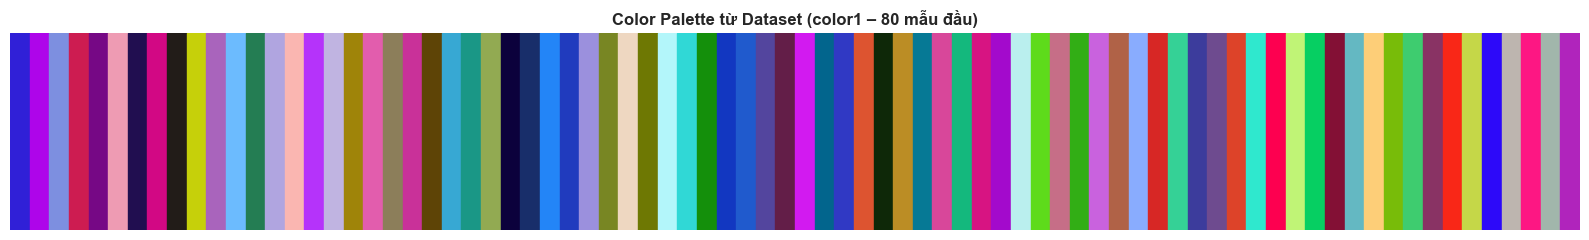

In [43]:
# ── Color palette visualization từ dataset ────────────────────────────────────
valid_hex = df["color1"].dropna().head(80).str.strip()
valid_hex = [c for c in valid_hex if re.match(r'^#[0-9A-Fa-f]{6}$', c)]

fig2, ax = plt.subplots(figsize=(16, 2.5))
ax.set_xlim(0, len(valid_hex)); ax.set_ylim(0, 1)
for i, hex_c in enumerate(valid_hex):
    rgb = tuple(int(hex_c.lstrip("#")[j:j+2], 16)/255 for j in (0,2,4))
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb))
ax.axis("off")
ax.set_title("Color Palette từ Dataset (color1 – 80 mẫu đầu)", fontweight="bold")
plt.tight_layout()
plt.show()

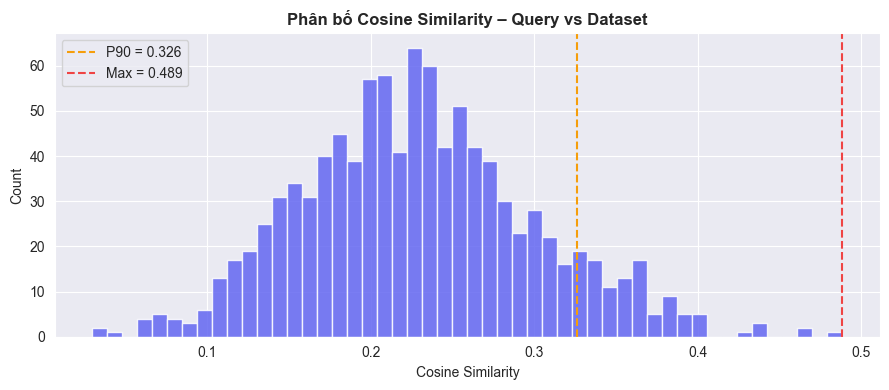

In [44]:
# ── Similarity score distribution ────────────────────────────────────────────
q_emb_viz   = encode_query("simple clean space neutral colors open areas")
sims_all    = cosine_similarity(q_emb_viz, dataset_embeddings)[0]

plt.figure(figsize=(9, 4))
plt.hist(sims_all, bins=50, color="#6366f1", edgecolor="white", alpha=0.85)
plt.axvline(np.percentile(sims_all, 90), color="#f59e0b", linestyle="--",
            label=f"P90 = {np.percentile(sims_all,90):.3f}")
plt.axvline(sims_all.max(), color="#ef4444", linestyle="--",
            label=f"Max = {sims_all.max():.3f}")
plt.xlabel("Cosine Similarity"); plt.ylabel("Count")
plt.title("Phân bố Cosine Similarity – Query vs Dataset", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Lưu Models & Artifacts

In [45]:

os.makedirs("models", exist_ok=True)

joblib.dump(style_clf,    "models/style_model.pkl")
joblib.dump(material_clf, "models/material_model.pkl")
joblib.dump(color_reg,    "models/color_model.pkl")
joblib.dump(tfidf_style,  "models/tfidf_style.pkl")
joblib.dump(tfidf_material, "models/tfidf_material.pkl")

joblib.dump({
    "style_names":      STYLE_NAMES,
    "material_names":   MATERIAL_NAMES,
    "st_model_name":    "all-MiniLM-L6-v2",
    "color_palette":    COLOR_PALETTE_TABLE,
}, "models/metadata.pkl")

print("Đã lưu models thành công!")


Đã lưu models thành công!


---

## Tóm tắt pipeline

| Bước | Module | Mô tả |
|---|---|---|
| 1 | `build_feature_vector()` | Keyword matching → (1×12) feature vector |
| 2 | `style_clf` (RF) | Phân loại phong cách thiết kế (4 nhãn) |
| 3 | `material_clf` (RF) | Phân loại vật liệu (8 nhãn) |
| 4 | `color_reg` (MultiOutput RF) | Dự đoán 3 màu RGB |
| 5 | `SentenceTransformer` | Encode query → vector 384d |
| 6 | `cosine_similarity()` | Tìm Top-N mẫu tương đồng nhất |

### Giá trị học thuật
- End-to-end ML pipeline: NLP + Classification + Regression + Similarity Search
- Kết hợp supervised learning (RF) với semantic search (Sentence-BERT)
- MultiOutput regression cho bài toán dự đoán đa mục tiêu
- Hybrid filtering: ML prediction filter → vector similarity ranking
